## MULTİPLE POLYNOMİAL REGRESSİON

In [2]:
#Gerekli kütüphanelerin indirilmesi:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import linear_model
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error


In [3]:
# Veri setini indirelim.
veri= pd.read_excel("https://www.dropbox.com/s/luoopt5biecb04g/SATILK_EV1.xlsx?dl=1",index_col=0)
veri.head()

,Fiyat,Oda_Sayısı,Net_m2,Katı,Yaşı
0,475,1,40,0,6
1,475,1,55,0,5
2,450,1,50,0,7
3,450,1,55,1,6
4,475,1,45,2,7


In [4]:
# Hedef ve öznitelik değişkenlerini (x) tanımlayalım,Veriyi bölelim:
x=veri [["Oda_Sayısı","Net_m2","Katı","Yaşı"]]
y=veri["Fiyat"]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [5]:
#Polinom Derecesi oluşturma fonksiyon:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline


In [ ]:
# 2. den 10. dereceye kadar oznitelik degişkenlerinin polinom derecelerini oluşturup
#  herbir polinom ile oluşturulan modelin hata skorunu hesaplatıyrouz.Burada hata skoru olarak RMSE kullanıyoruz.

rmses=[]
degrees =np.arange(1,10)
min_rmse,min_deg =1e10,0



In [ ]:
# R2 yerine RMSE kullanamak daha fayadlı ,R2 asiri duyarlı oluyor cunku polinomlarda

for deg in degrees:

    #Egitim seti oznitelikleri
    poly_feattures=PolynomialFeatures(degree=deg,include_bias=False)
    x_poly_train=poly_feattures.fit_transform(x_train)

    #Doğrusal Regresyon
    poly_reg=LinearRegression()
    poly_reg.fit(x_poly_train,y_train)

    #Test seti ile karsilastirma:
    x_poly_test=poly_feattures.fit_transform(x_test)
    poly_predict=poly_reg.predict(x_poly_test)
    poly_mse=mean_squared_error(y_test,poly_predict)
    poly_rmse=np.sqrt(poly_mse)
    rmses.append(poly_rmse)

    #Capraz dogrulama ile polinom dereceleri:
    if min_rmse > poly_rmse:
        min_rmse=poly_rmse
        min_deg=deg


In [8]:
#En düsük RMSE hata skorunu veren moedlin polinom derecesi::
print(f"En iyi model {min_rmse} RMSE hata skorunu veren {min_deg} polinom derecesi le saglaniyor.")

En iyi model 56.48843719880822 RMSE hata skorunu veren 2 polinom derecesi le saglaniyor.


Text(5.2, 200, 'En iyi hata skorunu veren \nPolinom derecesi: 2 \nRMSE skoru: 56.48843719880822')

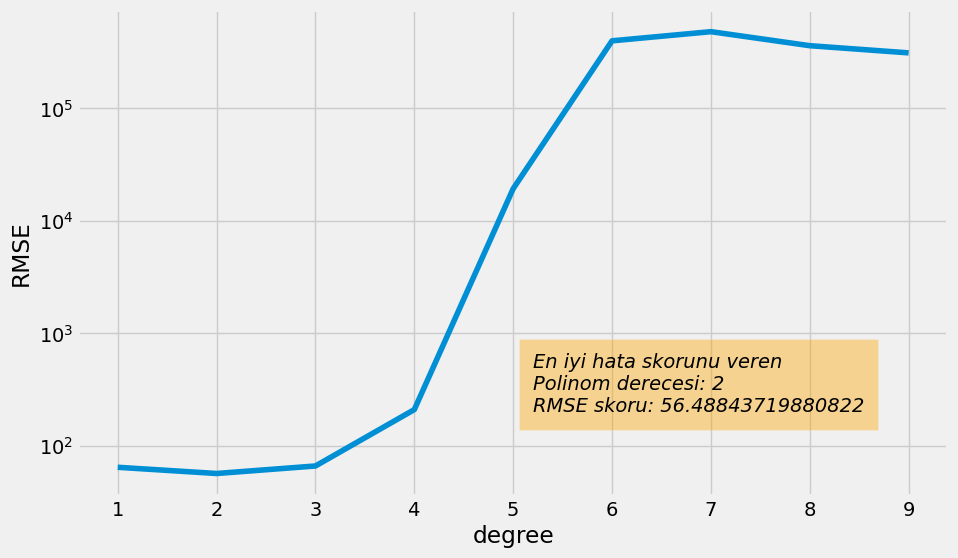

In [9]:
#Grafik: Tum polinom dereceleri için RMSE skorları:
plt.style.use("fivethirtyeight")
fig=plt.figure(figsize=(10,6))
ax=fig.add_subplot(111)
ax.plot(degrees,rmses)
ax.set_yscale("log")
ax.set_xlabel("degree")
ax.set_ylabel("RMSE")
plt.text(5.2,200,f"En iyi hata skorunu veren \nPolinom derecesi: {min_deg} \nRMSE skoru: {min_rmse}",style="italic",
         bbox={"facecolor":"orange","alpha":0.4,"pad":10})


In [10]:
#Oznitelik degiskeninin karesel derecesini belirleyelim:
polinom_derecesi=PolynomialFeatures(degree=2)
x_train_polinom=polinom_derecesi.fit_transform(x_train)
x_test_polinom=polinom_derecesi.transform(x_test)


In [11]:
#Polinom regresyon algoritmasını egitiyoruz:
polinom_regresyon=LinearRegression()
polinom_regresyon.fit(x_train_polinom,y_train)

model=LinearRegression()
model.fit(x_train,y_train)


LinearRegression()

In [13]:
#Coklu dogrusal modelin egitim ve test setleri icin ongoru performansi:
print("Dogrusal Reg train r2:",model.score(x_train,y_train))
print("Dogrusal Reg test r2:",model.score(x_test,y_test))


Dogrusal Reg train r2: 0.733739961656849
Dogrusal Reg test r2: 0.6987282352837989


In [15]:
#Coklu polinom regresyon egitim ve test setleri icin ongoru performansı:
print("Polinom Reg train r2:",polinom_regresyon.score(x_train_polinom,y_train))
print("Polinom Reg test r2:",polinom_regresyon.score(x_test_polinom,y_test))

Polinom Reg train r2: 0.8488074651060601
Polinom Reg test r2: 0.7663814623333197


In [16]:
#Egitim veri seti icin tahmin edilen degerleri ile karsilastirması :
y_pred_egitim=polinom_regresyon.predict(x_train_polinom)
for i,prediction in enumerate(y_pred_egitim):
    print("Tahmin Edilen Ev Fiyatı: %.2f, Gerçek Ev Fiyatı: %s" % (prediction, y_train.iloc[i]))

Tahmin Edilen Ev Fiyatı: 554.88, Gerçek Ev Fiyatı: 525
Tahmin Edilen Ev Fiyatı: 674.06, Gerçek Ev Fiyatı: 650
Tahmin Edilen Ev Fiyatı: 573.14, Gerçek Ev Fiyatı: 550
Tahmin Edilen Ev Fiyatı: 676.69, Gerçek Ev Fiyatı: 675
Tahmin Edilen Ev Fiyatı: 691.73, Gerçek Ev Fiyatı: 675
Tahmin Edilen Ev Fiyatı: 637.82, Gerçek Ev Fiyatı: 625
Tahmin Edilen Ev Fiyatı: 563.65, Gerçek Ev Fiyatı: 575
Tahmin Edilen Ev Fiyatı: 642.74, Gerçek Ev Fiyatı: 650
Tahmin Edilen Ev Fiyatı: 560.85, Gerçek Ev Fiyatı: 600
Tahmin Edilen Ev Fiyatı: 703.11, Gerçek Ev Fiyatı: 775
Tahmin Edilen Ev Fiyatı: 907.04, Gerçek Ev Fiyatı: 800
Tahmin Edilen Ev Fiyatı: 560.85, Gerçek Ev Fiyatı: 500
Tahmin Edilen Ev Fiyatı: 738.98, Gerçek Ev Fiyatı: 725
Tahmin Edilen Ev Fiyatı: 496.73, Gerçek Ev Fiyatı: 550
Tahmin Edilen Ev Fiyatı: 533.51, Gerçek Ev Fiyatı: 625
Tahmin Edilen Ev Fiyatı: 666.58, Gerçek Ev Fiyatı: 650
Tahmin Edilen Ev Fiyatı: 551.91, Gerçek Ev Fiyatı: 500
Tahmin Edilen Ev Fiyatı: 660.30, Gerçek Ev Fiyatı: 675
Tahmin Edi

In [18]:
# Test veri seti için tahmin edilen değerleri gerçek değerlerle karşılaştıralım

y_pred_test = polinom_regresyon.predict(x_test_polinom)

for i, prediction in enumerate(y_pred_test):
    print("Tahmin Edilen Ev Fiyatı: %.2f, Gerçek Ev Fiyatı: %s" % (prediction, y_test.iloc[i]))

Tahmin Edilen Ev Fiyatı: 725.84, Gerçek Ev Fiyatı: 775
Tahmin Edilen Ev Fiyatı: 681.91, Gerçek Ev Fiyatı: 600
Tahmin Edilen Ev Fiyatı: 749.01, Gerçek Ev Fiyatı: 750
Tahmin Edilen Ev Fiyatı: 664.65, Gerçek Ev Fiyatı: 700
Tahmin Edilen Ev Fiyatı: 643.60, Gerçek Ev Fiyatı: 625
Tahmin Edilen Ev Fiyatı: 542.51, Gerçek Ev Fiyatı: 575
Tahmin Edilen Ev Fiyatı: 519.79, Gerçek Ev Fiyatı: 475
Tahmin Edilen Ev Fiyatı: 514.63, Gerçek Ev Fiyatı: 500
Tahmin Edilen Ev Fiyatı: 637.79, Gerçek Ev Fiyatı: 650
Tahmin Edilen Ev Fiyatı: 674.06, Gerçek Ev Fiyatı: 600
Tahmin Edilen Ev Fiyatı: 647.14, Gerçek Ev Fiyatı: 625
Tahmin Edilen Ev Fiyatı: 745.83, Gerçek Ev Fiyatı: 775
Tahmin Edilen Ev Fiyatı: 516.32, Gerçek Ev Fiyatı: 525
Tahmin Edilen Ev Fiyatı: 753.65, Gerçek Ev Fiyatı: 750
Tahmin Edilen Ev Fiyatı: 674.06, Gerçek Ev Fiyatı: 650
Tahmin Edilen Ev Fiyatı: 820.31, Gerçek Ev Fiyatı: 950
Tahmin Edilen Ev Fiyatı: 753.65, Gerçek Ev Fiyatı: 775
Tahmin Edilen Ev Fiyatı: 669.22, Gerçek Ev Fiyatı: 725
Tahmin Edi

In [22]:
# Tüm veri seti için tahminler

x_poly = polinom_derecesi.transform(x)

veri['Fiyat_Tahmini'] = polinom_regresyon.predict(x_poly)

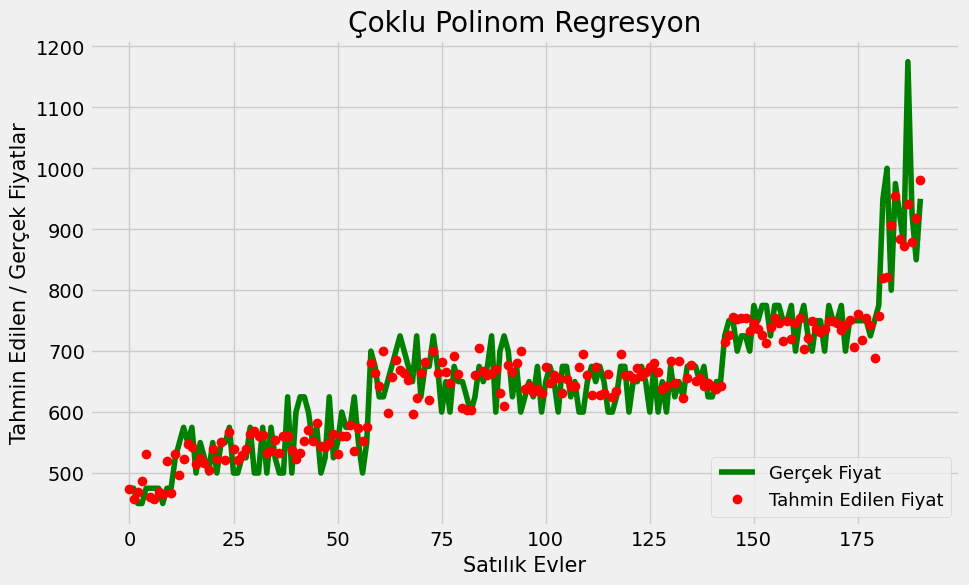

In [23]:
# Grafik: Gerçek ve Tahmin Edilen Ev Fiyatlarının Karşılaştırılması

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.style.use('fivethirtyeight')

plt.title('Çoklu Polinom Regresyon')

plt.plot(veri['Fiyat'], 'g', label='Gerçek Fiyat')
plt.plot(veri['Fiyat_Tahmini'], 'ro', label='Tahmin Edilen Fiyat')

plt.xlabel('Satılık Evler', fontsize=15)
plt.ylabel('Tahmin Edilen / Gerçek Fiyatlar', fontsize=15)

plt.legend(fontsize=13, loc='lower right')

plt.show()